# UNSW-NB15 Preprocessing

**Flow:** load -> EDA -> dedup -> split -> clean -> feature selection -> transform -> SMOTE -> export

Rules followed everywhere:
- The test set never influences a decision. Every fitted value (medians, rare levels, scalers, rankings) comes from train only.
- SMOTE runs on train only, after the split and all transforms.

In [ ]:
import glob

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

RAW_DIR = "/kaggle/input/datasets/shahiismyname/unsw-nb15-raw-dataset"
OUT_DIR = "/kaggle/working"
SEED = 42

## 1. Load and combine the 4 raw files

In [2]:
names = (pd.read_csv(f"{RAW_DIR}/NUSW-NB15_features.csv", encoding="latin-1")["Name"]
           .str.replace(" ", "").str.strip().tolist())

files = sorted(glob.glob(f"{RAW_DIR}/UNSW-NB15_RAW_FILES/*.csv"))
df = pd.concat(
    (pd.read_csv(f, header=None, names=names, dtype={"sport": str, "dsport": str}, low_memory=False)
     for f in files),
    ignore_index=True,
)
df["attack_cat"] = df["attack_cat"].fillna("Normal").str.strip().replace({"Backdoors": "Backdoor"})
print(len(files), "files |", df.shape)

4 files | (2540047, 49)


Two raw-data quirks handled here:
- Some ports are hex strings (`0xc0a8`) or `-`. Plain `to_numeric` turns hex into NaN, so hex is decoded first.
- `ct_ftp_cmd`, `is_ftp_login`, `ct_flw_http_mthd` contain blanks. They are converted to numbers (blank becomes NaN) and filled later using train medians.

In [3]:
def parse_port(s):
    s = s.fillna("-").str.strip()
    is_hex = s.str.startswith("0x")
    port = pd.to_numeric(s.where(~is_hex), errors="coerce")
    port[is_hex] = s[is_hex].apply(int, base=16)
    return port


for c in ["sport", "dsport"]:
    df[c] = parse_port(df[c])

for c in ["ct_ftp_cmd", "is_ftp_login", "ct_flw_http_mthd"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("missing ports (sentinels):", df[["sport", "dsport"]].isna().sum().to_dict())

missing ports (sentinels): {'sport': 2, 'dsport': 7}


## 2. EDA on the raw data

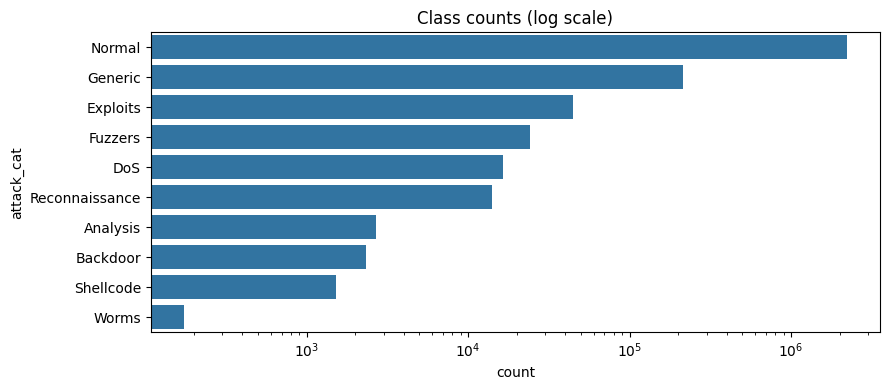

attack_cat
Normal            2218764
Generic            215481
Exploits            44525
Fuzzers             24246
DoS                 16353
Reconnaissance      13987
Analysis             2677
Backdoor             2329
Shellcode            1511
Worms                 174
Name: count, dtype: int64

In [4]:
order = df["attack_cat"].value_counts().index
plt.figure(figsize=(9, 4))
sns.countplot(data=df, y="attack_cat", order=order)
plt.xscale("log")
plt.title("Class counts (log scale)")
plt.tight_layout()
plt.show()
df["attack_cat"].value_counts()

In [5]:
# Blank rate by class. If it differs a lot, the blank itself carries information.
blank_cols = ["ct_ftp_cmd", "is_ftp_login", "ct_flw_http_mthd"]
df[blank_cols].isna().groupby(df["attack_cat"]).mean().round(2)

,ct_ftp_cmd,is_ftp_login,ct_flw_http_mthd
attack_cat,,,
Analysis,0.80,0.80,0.60
Backdoor,0.77,0.77,0.74
DoS,0.93,0.93,0.84
Exploits,0.84,0.84,0.66
Fuzzers,0.79,0.79,0.75
Generic,0.97,0.97,0.96
Normal,0.51,0.51,0.48
Reconnaissance,0.87,0.87,0.75
Shellcode,0.85,0.85,0.85


## 3. Remove duplicates, then split

A duplicate means same features **and** same label (IDs, timestamps and `Label` ignored). Dedup runs before the split so a row can't land in both train and test.

In [6]:
ID_COLS = ["srcip", "dstip", "stcpb", "dtcpb", "Stime", "Ltime", "Label"]
dup_cols = [c for c in df.columns if c not in ID_COLS]   # includes attack_cat

before = df["attack_cat"].value_counts()
df = df.drop_duplicates(subset=dup_cols)      # keeps the original row index as row_id
after = df["attack_cat"].value_counts()

pd.DataFrame({"before": before, "after": after}).assign(removed_pct=lambda t: (100 * (1 - t.after / t.before)).round(1))

,before,after,removed_pct
attack_cat,,,
Analysis,2677,2033,24.1
Backdoor,2329,1881,19.2
DoS,16353,5514,66.3
Exploits,44525,27444,38.4
Fuzzers,24246,21644,10.7
Generic,215481,20035,90.7
Normal,2218764,1948901,12.2
Reconnaissance,13987,13206,5.6
Shellcode,1511,1511,0.0


**Label overlap check.** Dedup removed rows with the same features **and** the same label. Any group of feature-identical rows still left therefore carries *different* labels. No model that only sees these features can tell such rows apart, so they are direct evidence of class overlap (the effect behind the weak Analysis / Backdoor scores). The chart shows, per class, what share of its rows has a feature-identical row from another class.

In [ ]:
feat_cols = [c for c in dup_cols if c != "attack_cat"]
conflict = df[df.duplicated(subset=feat_cols, keep=False)]
print(f"{len(conflict)} of {len(df)} rows ({len(conflict) / len(df):.2%}) share every feature with a differently-labelled row")

raw_conflict_share = (conflict["attack_cat"].value_counts() / df["attack_cat"].value_counts()).fillna(0).sort_values()
print(raw_conflict_share.round(4).to_string())

# Which label combinations collide most often?
combos = conflict.groupby(feat_cols, dropna=False)["attack_cat"].agg(lambda s: " | ".join(sorted(set(s))))
print("\nmost common colliding label sets (number of feature-identical groups):")
print(combos.value_counts().head(10).to_string())

raw_conflict_share.plot.barh(figsize=(7, 4), color="crimson")
plt.xlabel("share of the class's rows that have a feature-identical row from another class")
plt.title("Label overlap in the raw data (after dedup)")
plt.tight_layout()
plt.show()

In [7]:
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["attack_cat"], random_state=SEED)
print(train_df.shape, test_df.shape)

# Graph anchors for the GNN (real IPs, ports, timestamps). Index = row_id.
GRAPH_COLS = ["srcip", "dstip", "sport", "dsport", "Stime", "Ltime"]
train_graph, test_graph = train_df[GRAPH_COLS].copy(), test_df[GRAPH_COLS].copy()

y_train, y_test = train_df["attack_cat"], test_df["attack_cat"]

(1633872, 49) (408468, 49)


## 4. Clean (fit on train, apply to both)

- Drop identifiers and `Label` (IP, TCP sequence numbers and timestamps are testbed artifacts, `Label` leaks the target).
- Fill missing values with the **train** median.
- `is_ftp_login` becomes a 0/1 flag.
- `sport` becomes 4 range bins. `dsport` stays numeric (about 33k distinct values, and numeric tested at least as well as bins).
- `proto`, `state`, `service`: levels under 0.5% of train become `Other`.

In [8]:
CAT_COLS = ["proto", "state", "service"]
raw_numeric = [c for c in train_df.columns if c not in ID_COLS + CAT_COLS + ["attack_cat"]]

fill_values = train_df[raw_numeric].median()

keep_levels = {}
for c in CAT_COLS:
    freq = train_df[c].value_counts(normalize=True)
    keep_levels[c] = set(freq[freq >= 0.005].index)


def clean(d):
    d = d.drop(columns=ID_COLS + ["attack_cat"]).fillna(fill_values)
    d["is_ftp_login"] = (d["is_ftp_login"] > 0).astype(int)
    d["sport_bin"] = pd.cut(d["sport"], [-1, 0, 1023, 49151, 65535],
                            labels=["zero", "well_known", "registered", "ephemeral"]).astype(str)
    d = d.drop(columns="sport")
    for c in CAT_COLS:
        d[c] = d[c].where(d[c].isin(keep_levels[c]), "Other")
    return d


X_train, X_test = clean(train_df), clean(test_df)
cat_cols = CAT_COLS + ["sport_bin"]
print(X_train.shape, X_test.shape, "| missing left:", int(X_train.isna().sum().sum()), int(X_test.isna().sum().sum()))

(1633872, 41) (408468, 41) | missing left: 0 0


**Missing-value check.** Only `ct_ftp_cmd`, `is_ftp_login`, `ct_flw_http_mthd` have real missing values (ports were already handled above). The rule: test's missing values get filled with the **train** median for that column - never a value computed from test itself.

In [ ]:
missing = pd.DataFrame({
    "train_missing": train_df[raw_numeric].isna().sum(),
    "test_missing": test_df[raw_numeric].isna().sum(),
}).query("train_missing > 0 or test_missing > 0")
missing["train_median_used"] = fill_values[missing.index]

missing[["train_missing", "test_missing"]].plot.barh(figsize=(7, 3), color=["#4C72B0", "#DD8452"])
plt.xlabel("rows missing (before fill)")
plt.title("Missing values, train vs test - both filled with the train value on the right")
plt.tight_layout()
plt.show()

missing

In [9]:
# Report only: test rows whose features exactly match a train row (any label).
h_train = pd.util.hash_pandas_object(X_train, index=False)
h_test = pd.util.hash_pandas_object(X_test, index=False)
print(f"test rows matching a train row: {h_test.isin(set(h_train)).sum()} of {len(X_test)}")

test rows matching a train row: 5959 of 408468


## 5. EDA on cleaned train

Four checks before feature selection, all computed on **train** only:
1. **Outliers** - one boxplot per feature, own scale, 3 per row.
2. **Skewness** - flags which features need the `log1p` treatment used later in step 7.
3. **Correlation** - heatmap + the near-duplicate pairs that drive step 6's redundant-feature drop.
4. **Linearity** - scatterplots for the flagged pairs (is it really a straight line?), plus a 2D PCA to see whether classes separate linearly at all.

In [ ]:
num_cols = X_train.select_dtypes("number").columns.tolist()
sample_out = X_train[num_cols].sample(100_000, random_state=SEED)

ncols = 3
nrows = -(-len(num_cols) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 2.8))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(x=sample_out[col], ax=ax, color="steelblue", width=0.5,
                flierprops={"marker": "o", "markersize": 4, "markerfacecolor": "crimson",
                            "markeredgecolor": "none", "alpha": 0.4})
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
for ax in axes.flat[len(num_cols):]:
    ax.axis("off")

plt.suptitle("Outliers by feature (train, 100k-row sample, own scale per feature)", y=1.0, fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
skew_vals = X_train[num_cols].skew().sort_values()
colors = ["crimson" if abs(v) > 2 else "steelblue" for v in skew_vals]

plt.figure(figsize=(7, 9))
plt.barh(skew_vals.index, skew_vals.values, color=colors)
plt.axvline(2, color="crimson", ls="--", lw=1, label="log1p cutoff (step 7)")
plt.legend()
plt.xlabel("skew")
plt.title("Skewness by feature (train)")
plt.tight_layout()
plt.show()

In [ ]:
corr = X_train[num_cols].corr()
heatmap_mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)   # symmetric matrix, hide the mirrored upper half

annot = corr.round(2).astype(str)
annot[corr.abs() < 0.3] = ""   # only label correlations worth a second look, cuts the clutter

plt.figure(figsize=(16, 13))
sns.heatmap(corr, mask=heatmap_mask, cmap="coolwarm", vmin=-1, vmax=1, center=0,
            annot=annot, fmt="", annot_kws={"size": 6}, square=True, linewidths=0.3,
            cbar_kws={"label": "Pearson r", "shrink": 0.8})
plt.title("Pearson correlation (train) - numbers shown where |r| >= 0.3")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

upper = corr.abs().where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
upper[upper >= 0.9].sort_values(ascending=False).round(3)

In [ ]:
top_pairs = upper[upper >= 0.9].sort_values(ascending=False)
labels = [f"{a} - {b}" for a, b in top_pairs.index]

plt.figure(figsize=(7, 4))
plt.barh(labels, top_pairs.values, color="darkorange")
plt.gca().invert_yaxis()
plt.xlim(0.85, 1.0)
plt.xlabel("|Pearson r|")
plt.title("Near-duplicate pairs, |r| >= 0.9 (train)")
plt.tight_layout()
plt.show()

top_pairs.round(3)

In [ ]:
sample_sc = X_train.sample(5000, random_state=SEED)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, (a, b) in zip(axes.flat, top_pairs.index):
    ax.scatter(sample_sc[a], sample_sc[b], s=3, alpha=0.3)
    ax.set_xlabel(a)
    ax.set_ylabel(b)
    ax.set_title(f"r = {top_pairs[(a, b)]:.3f}")
plt.suptitle("Are the flagged pairs actually linear? A straight line confirms redundancy, a cloud wouldn't.")
plt.tight_layout()
plt.show()

In [ ]:
sample_idx_pca = pd.concat([g.sample(min(len(g), 2000), random_state=SEED) for _, g in y_train.groupby(y_train)]).index
coords = PCA(n_components=2, random_state=SEED).fit_transform(
    StandardScaler().fit_transform(X_train.loc[sample_idx_pca, num_cols])
)

plt.figure(figsize=(11, 8))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=y_train.loc[sample_idx_pca].values,
                 palette="tab10", s=40, alpha=0.75, linewidth=0.2, edgecolor="white")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9, title="attack_cat", markerscale=1.5)
plt.title("2D PCA, train (class-balanced sample) - heavy overlap means no simple linear boundary")
plt.tight_layout()
plt.show()

## 6. Feature selection (train only)

Three steps, from cheap to expensive:
1. **Redundant features:** one of each near-duplicate pair is dropped (see the pair chart and scatterplots above). Pearson >= 0.99 for `dloss`/`dbytes` and `dloss`/`Dpkts`, and for `dwin`/`swin`; `sloss` is dropped too - 0.96 with `sbytes` (same loss/byte-count family), just under the 0.99 cut, backed by the val check below. `tcprtt` correlates 0.930 with `synack` and 0.916 with `ackdat` (it's literally their sum); `ct_ftp_cmd` correlates 0.923 with `is_ftp_login` (blank on the same rows).
2. **Near-constant features:** one value in more than 99.8% of rows.
3. **Ranking:** mutual information, ANOVA F, decision tree and random forest, on a class-balanced sample. The methods disagree often (linear vs non-linear), so a feature is dropped only if it sits in the **bottom quarter on every method**.

In [ ]:
#check the actual corr pairs backing the "redundant" list below, instead of trusting the markdown comment blindly.
print("corr >= 0.99 pairs (train):\n", upper[upper >= 0.99])
print("\nsloss top correlations (train):\n", corr["sloss"].drop("sloss").abs().sort_values(ascending=False).round(3).head(5))
print("\ntcprtt vs synack/ackdat:", corr.loc["tcprtt", ["synack", "ackdat"]].round(3).to_dict())
print("ct_ftp_cmd vs is_ftp_login:", round(corr.loc["ct_ftp_cmd", "is_ftp_login"], 3))

redundant = ["dwin", "dloss", "sloss", "tcprtt", "ct_ftp_cmd"]
near_constant = [c for c in num_cols if X_train[c].value_counts(normalize=True).iloc[0] > 0.998]
print("near constant:", near_constant)

candidates = [c for c in X_train.columns if c not in redundant + near_constant]

In [13]:
# Category columns as integer codes, only for ranking (trees and MI need numbers).
X_codes = X_train[candidates].copy()
for c in cat_cols:
    X_codes[c] = X_codes[c].astype("category").cat.codes

# Hold out 20% of train to check the selection; rank on a balanced sample of the rest.
fit_idx, val_idx = train_test_split(X_train.index, test_size=0.2, stratify=y_train, random_state=SEED)
y_fit = y_train.loc[fit_idx]
sample_idx = pd.concat([g.sample(min(len(g), 3000), random_state=SEED) for _, g in y_fit.groupby(y_fit)]).index

Xs, ys = X_codes.loc[sample_idx], y_train.loc[sample_idx]
discrete = [c in cat_cols or Xs[c].nunique() <= 20 for c in Xs.columns]
numeric_only = [c for c in Xs.columns if c not in cat_cols]

scores = pd.DataFrame(index=Xs.columns)
scores["MI"] = mutual_info_classif(Xs, ys, discrete_features=discrete, random_state=SEED)
scores["ANOVA_F"] = pd.Series(f_classif(np.log1p(Xs[numeric_only].clip(lower=0)), ys)[0], index=numeric_only)
scores["DecisionTree"] = DecisionTreeClassifier(max_depth=12, class_weight="balanced", random_state=SEED).fit(Xs, ys).feature_importances_
scores["RandomForest"] = RandomForestClassifier(n_estimators=100, max_depth=14, class_weight="balanced_subsample",
                                                n_jobs=-1, random_state=SEED).fit(Xs, ys).feature_importances_

ranks = scores.rank(ascending=False)
ranks["best_rank"] = ranks.min(axis=1)
ranks.sort_values("best_rank")

,MI,ANOVA_F,DecisionTree,RandomForest,best_rank
dsport,2.0,7.0,2.0,1.0,1.0
sbytes,1.0,20.0,1.0,2.0,1.0
ct_state_ttl,10.0,1.0,21.0,7.0,1.0
sttl,7.0,2.0,3.0,3.0,2.0
smeansz,3.0,28.0,7.0,4.0,3.0
Dload,8.0,3.0,18.0,14.0,3.0
proto,24.0,NaN,4.0,11.0,4.0
Sload,4.0,25.0,9.0,15.0,4.0
ct_dst_sport_ltm,25.0,4.0,28.0,22.0,4.0
service,16.0,NaN,5.0,9.0,5.0


In [14]:
weak = ranks.index[ranks["best_rank"] > 0.75 * len(ranks)].tolist()
print("dropped by ranking:", weak)

final_cols = [c for c in candidates if c not in weak]
print(len(X_train.columns), "->", len(final_cols), "features")

dropped by ranking: ['state', 'is_ftp_login']
41 -> 33 features


In [15]:
# Sanity check on the held-out part of train: does the smaller set lose accuracy?
def val_macro_f1(cols):
    rf = RandomForestClassifier(n_estimators=100, max_depth=14, class_weight="balanced_subsample",
                                n_jobs=-1, random_state=SEED)
    rf.fit(X_codes.loc[sample_idx, cols], ys)
    pred = rf.predict(X_codes.loc[val_idx, cols])
    return round(f1_score(y_train.loc[val_idx], pred, average="macro"), 4)


print("all candidates :", val_macro_f1(candidates))
print("selected       :", val_macro_f1(final_cols))

all candidates : 0.5924
selected       : 0.5954


In [16]:
X_train, X_test = X_train[final_cols], X_test[final_cols]

## 7. Transform (fit on train)

- Heavy-tailed non-negative columns (skew > 2): `log1p`, then standardize.
- Other numeric columns: standardize.
- 0/1 flags pass through. Categorical strings are one-hot encoded right here, before SMOTE (not after, like the previous version) - step 8 uses BorderlineSMOTE, which needs fully numeric input to find minority points near the class boundary.

In [ ]:
cat_final = [c for c in cat_cols if c in final_cols]
binary_cols = [c for c in final_cols if c not in cat_final and X_train[c].isin([0, 1]).all()]
numeric_cols = [c for c in final_cols if c not in cat_final + binary_cols]

skewed = [c for c in numeric_cols if X_train[c].skew() > 2 and X_train[c].min() >= 0]
plain = [c for c in numeric_cols if c not in skewed]
print("log1p + scale:", skewed)
print("scale only   :", plain)
print("binary       :", binary_cols, "| categorical:", cat_final)

prep = ColumnTransformer(
    [("log_scale", make_pipeline(FunctionTransformer(np.log1p, feature_names_out="one-to-one"), StandardScaler()), skewed),
     ("scale", StandardScaler(), plain)],
    remainder="passthrough", verbose_feature_names_out=False,
).set_output(transform="pandas")

X_train_p = prep.fit_transform(X_train)
X_test_p = prep.transform(X_test)

label_encoder = LabelEncoder().fit(y_train)

# One-hot encode here, before SMOTE, so BorderlineSMOTE (step 8) sees fully numeric data.
X_train_enc = pd.get_dummies(X_train_p, columns=cat_final, dtype="float32")
feature_names = X_train_enc.columns
X_test_enc = pd.get_dummies(X_test_p, columns=cat_final, dtype="float32").reindex(columns=feature_names, fill_value=0)
print(X_train_enc.shape, X_test_enc.shape)

In [ ]:
# Same overlap check on what the models actually see: the selected, transformed features of the train set.
row_hash = pd.util.hash_pandas_object(X_train_enc, index=False).to_numpy()
labels_in_group = y_train.groupby(row_hash).transform("nunique").to_numpy()
selected_conflict_share = pd.Series(labels_in_group > 1, index=y_train.index).groupby(y_train).mean()
print(f"train rows sharing every selected feature with a differently-labelled row: {(labels_in_group > 1).mean():.2%}")

overlap = pd.DataFrame({"raw features (after dedup)": raw_conflict_share,
                        "selected features (train)": selected_conflict_share}).sort_values("selected features (train)")
overlap.plot.barh(figsize=(8, 5), color=["lightcoral", "crimson"])
plt.xlabel("share of the class's rows with a feature-identical row from another class")
plt.title("Label overlap per class: before and after feature selection")
plt.tight_layout()
plt.show()
print(overlap.round(4).to_string())

## 8. Oversample the rare classes (train only)

The previous version used `SMOTENC`, which interpolates between any two random same-class neighbors - it adds volume to a rare class but not specifically where the model struggles. The first baseline run (see `analysis.md`) showed Analysis and Backdoor stuck at precision ~0.10-0.17, confused with Exploits: a boundary problem, not a volume problem.

`BorderlineSMOTE` only synthesizes near minority points that already sit close to the majority-class boundary, targeting that exact confusion directly.

Targets keep the same "raise classes under 5000" idea, but are capped at a 5x oversampling ratio instead of a flat 5000 - the previous version raised Worms from 137 to 5000 (36x), an extreme interpolation ratio for a class with so few real examples. The other four small classes were already within a 5x ratio of 5000, so they're unaffected.

The GNN needs real IPs, so it uses the **original** train set. The SMOTE set is for the tabular baselines.

In [ ]:
class_counts = y_train.value_counts()
targets = {c: min(5000, 5 * n) for c, n in class_counts.items() if n < 5000}
print("oversample targets (original -> target):", {c: (int(class_counts[c]), int(targets[c])) for c in targets})

smote = BorderlineSMOTE(sampling_strategy=targets, k_neighbors=5, m_neighbors=10, random_state=SEED)
X_smote, y_smote = smote.fit_resample(X_train_enc, y_train)
print(y_smote.value_counts().to_dict())

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts.sort_values().plot.barh(ax=axes[0], color="steelblue")
axes[0].set_xscale("log")
axes[0].set_xlabel("count (log scale)")
axes[0].set_title("Before SMOTE (train)")

y_smote.value_counts().sort_values().plot.barh(ax=axes[1], color="darkorange")
axes[1].set_xscale("log")
axes[1].set_xlabel("count (log scale)")
axes[1].set_title("After SMOTE (train)")

plt.suptitle("Class balance, before vs after SMOTE - small classes raised to 5000, big ones untouched")
plt.tight_layout()
plt.show()

## 9. Export

In [ ]:
train_out = X_train_enc.astype("float32")
test_out = X_test_enc.astype("float32")
smote_out = X_smote.reindex(columns=feature_names, fill_value=0).astype("float32")

train_out.index.name = test_out.index.name = "row_id"     # same row_id as the graph files

train_out.assign(label=label_encoder.transform(y_train)).to_parquet(f"{OUT_DIR}/train.parquet")
test_out.assign(label=label_encoder.transform(y_test)).to_parquet(f"{OUT_DIR}/test.parquet")
smote_out.assign(label=label_encoder.transform(y_smote)).to_parquet(f"{OUT_DIR}/train_smote.parquet")

train_graph.to_csv(f"{OUT_DIR}/train_graph.csv", index_label="row_id")
test_graph.to_csv(f"{OUT_DIR}/test_graph.csv", index_label="row_id")

joblib.dump({"prep": prep, "label_encoder": label_encoder, "fill_values": fill_values,
             "keep_levels": keep_levels, "final_cols": final_cols, "feature_names": list(feature_names)},
            f"{OUT_DIR}/preprocessing.pkl")

print("features:", len(feature_names))
print("train", train_out.shape, "| test", test_out.shape, "| train_smote", smote_out.shape)

**Outputs** (`/kaggle/working`)

| File | Use |
|---|---|
| `train.parquet`, `test.parquet` | Features + `label`, indexed by `row_id`. Use for the GNN (original class balance) |
| `train_smote.parquet` | Balanced train for tabular baselines |
| `train_graph.csv`, `test_graph.csv` | IPs, ports, timestamps by `row_id` for building the graph |
| `preprocessing.pkl` | Fitted transformers and label encoder |

For the GNN, the test set must stay invisible during message passing: build the training graph from `train_graph.csv` only.